In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import geopy
import plotly.express as px
import ast
import json
from pd_replicator import replicator
from datetime import datetime
import gc
pd.set_option('display.float_format', lambda x: '%.2f' % x)
pd.set_option('mode.use_inf_as_na', True)
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 200)
sns.set_style("whitegrid")
sns.set(rc={'figure.figsize':(10,6)})

/var/folders/g7/fm1k83t55yx3c4mjj3qk9sxr0000gn/T/ipykernel_40224/3665024186.py:14: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  pd.set_option('mode.use_inf_as_na', True)


# 1. Data Preparation

In [12]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load data (relative path)
df = pd.read_csv("../data/q2_customers.csv")

# Preview
df.head()

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Convert back to DataFrame (clean)
X_scaled = pd.DataFrame(X_scaled, columns=df.columns)

K-Means clustering is distance-based, meaning it relies on calculating distances between data points. If features are on different scales (e.g., age vs annual spend), variables with larger magnitudes will dominate the clustering process.

StandardScaler ensures that all features have a mean of 0 and standard deviation of 1, allowing each feature to contribute equally to the clustering algorithm.

# 2. Choosing K — Elbow Method

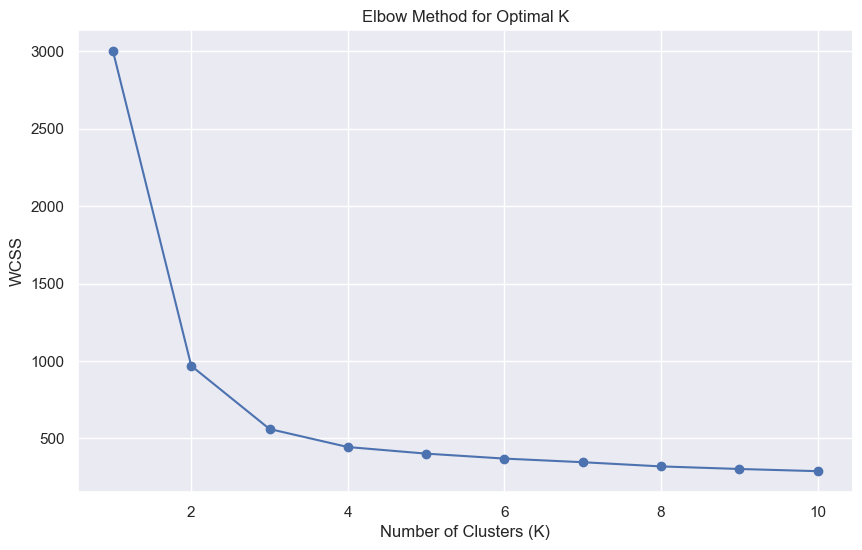

In [13]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot
plt.figure()
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

The elbow method plot shows a sharp decrease in WCSS from K = 1 to K = 3, indicating that adding clusters significantly improves the compactness of the clusters in this range.

After K = 3, the reduction in WCSS becomes much more gradual, suggesting diminishing returns from adding additional clusters.

Although K = 4 provides a slight improvement, the gain is marginal compared to the increase in model complexity.

Therefore, K = 3 is selected as the optimal number of clusters, as it achieves a good balance between cluster quality and simplicity.

# 3. K-Means Clustering

In [14]:
from sklearn.cluster import KMeans

# Use K = 3 (from elbow)
k = 3

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased,cluster
0,30,43075,9,2080,45,6,2
1,19,14496,11,454,8,3,0
2,43,57632,6,2144,16,4,2
3,30,15629,10,801,0,2,0
4,19,14901,16,396,17,1,0


In [16]:
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]  # exclude 'cluster'
)

centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.68,14847.37,14.34,558.97,9.08,2.11
1,56.77,89413.33,2.53,5530.55,105.36,7.52
2,40.39,43340.73,8.19,2021.68,35.19,4.42


**Cluster Interpretation:**

The clustering identifies three distinct customer segments:

- Cluster 0: Younger customers with high visit frequency but low spend and small basket sizes. These are frequent, low-value shoppers with upsell potential.

- Cluster 1: Older customers with very high spend and large basket sizes but low visit frequency and high recency. These are high-value customers at risk of churn and should be targeted for re-engagement.

- Cluster 2: Middle-aged customers with moderate spend, visit frequency, and recency. These are stable, mid-value customers with potential for growth.

Overall, the segments differentiate customers by value, engagement, and recency, enabling targeted strategies for retention, upselling, and growth.

# 4. Dimensionality Reduction with PCA

In [18]:
from sklearn.decomposition import PCA

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [19]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.83560354 0.05568764]


In [20]:
loadings = pd.DataFrame(
    pca.components_,
    columns=df.columns[:-1],  # exclude cluster column
    index=['PC1', 'PC2']
)

loadings

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.41,0.42,-0.41,0.41,0.38,0.41
PC2,-0.26,-0.03,0.21,-0.20,0.91,-0.14


**PCA Interpretation:**

The first principal component (PC1) explains approximately 83.6% of the total variance, indicating that it captures the majority of the information in the dataset. PC1 has strong positive loadings across features such as annual spend, basket size, number of categories purchased, and age, while visits per month has a negative loading. This suggests that PC1 represents overall customer value and purchase intensity, where higher values correspond to high-spending, high-basket customers who visit less frequently but spend more per visit.

The second principal component (PC2) explains a much smaller portion of variance (~5.6%) and is primarily driven by days since last visit, which has a very high positive loading. This indicates that PC2 captures customer recency or inactivity, distinguishing active customers from those who have not visited recently.

Overall, PC1 captures customer value and spending behavior, while PC2 captures recency and engagement patterns. Together, these components provide a meaningful low-dimensional representation of customer segments.

# 5. Cluster Visualisation

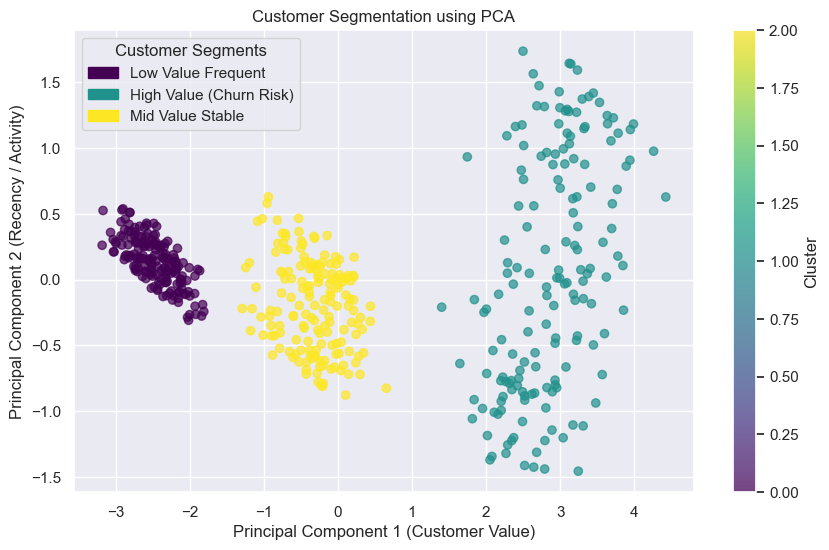

In [29]:
import matplotlib.patches as mpatches

plt.figure()

# Scatter
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df['cluster'],
    cmap='viridis',
    alpha=0.7
)

plt.title("Customer Segmentation using PCA")
plt.xlabel("Principal Component 1 (Customer Value)")
plt.ylabel("Principal Component 2 (Recency / Activity)")

# Colorbar
plt.colorbar(label="Cluster")

# Legend
legend_labels = {
    0: "Low Value Frequent",
    1: "High Value (Churn Risk)",
    2: "Mid Value Stable"
}

cmap = plt.cm.viridis
norm = plt.Normalize(vmin=df['cluster'].min(), vmax=df['cluster'].max())

patches = [
    mpatches.Patch(color=cmap(norm(i)), label=legend_labels[i])
    for i in sorted(df['cluster'].unique())
]

plt.legend(handles=patches, title="Customer Segments", loc='upper left')

plt.show()